Selected classes:
articleType
Tshirts         7066
Shirts          3215
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Name: count, dtype: int64


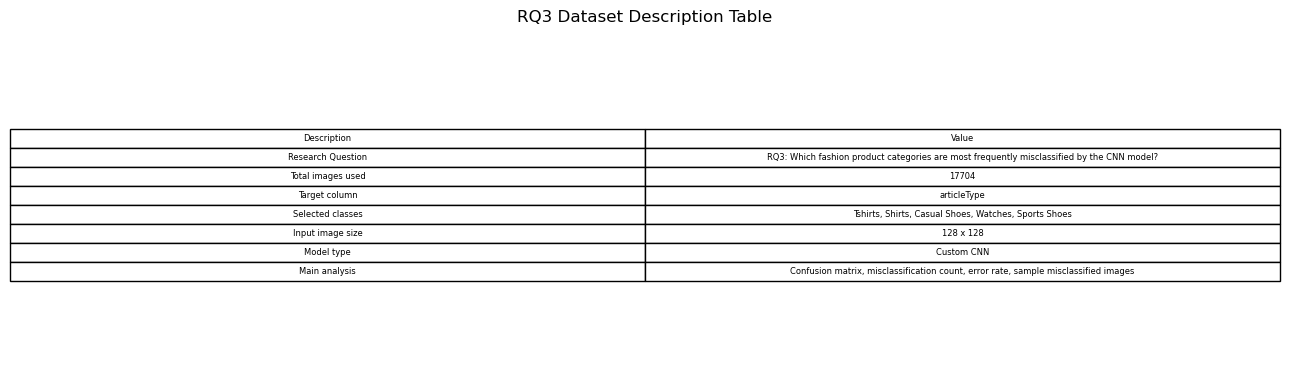

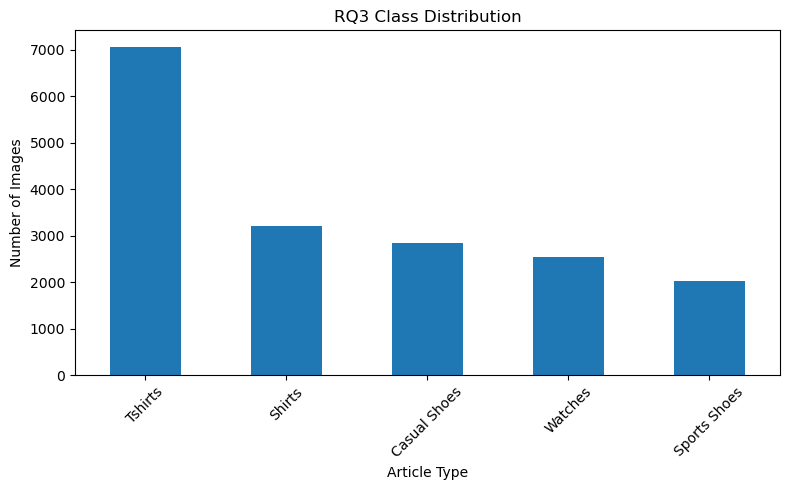

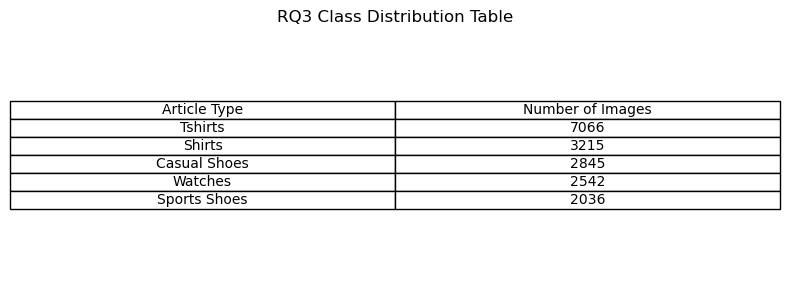

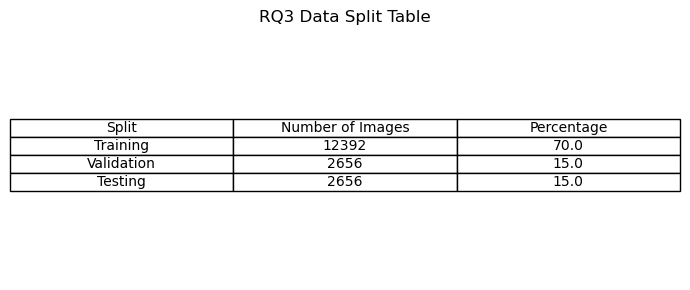

Found 12392 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.


C:\Users\hites\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,181 (12.61 MB)

 Trainable params: 3,305,733 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

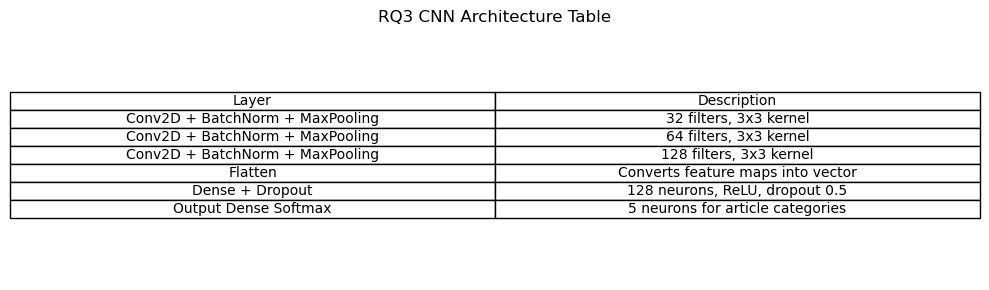

Epoch 1/3
388/388 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - accuracy: 0.7211 - loss: 0.8774 - val_accuracy: 0.7481 - val_loss: 0.7195
Epoch 2/3
388/388 ━━━━━━━━━━━━━━━━━━━━ 685s 2s/step - accuracy: 0.8034 - loss: 0.4860 - val_accuracy: 0.5542 - val_loss: 3.9480
Epoch 3/3
388/388 ━━━━━━━━━━━━━━━━━━━━ 683s 2s/step - accuracy: 0.8240 - loss: 0.4254 - val_accuracy: 0.7771 - val_loss: 0.5455


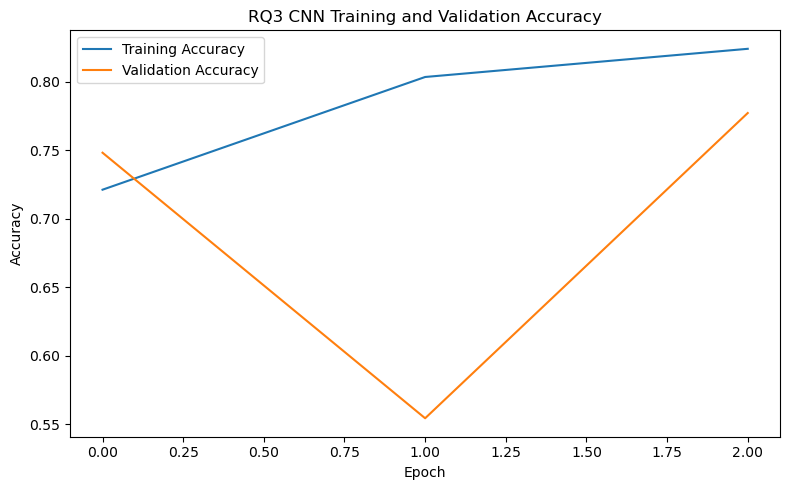

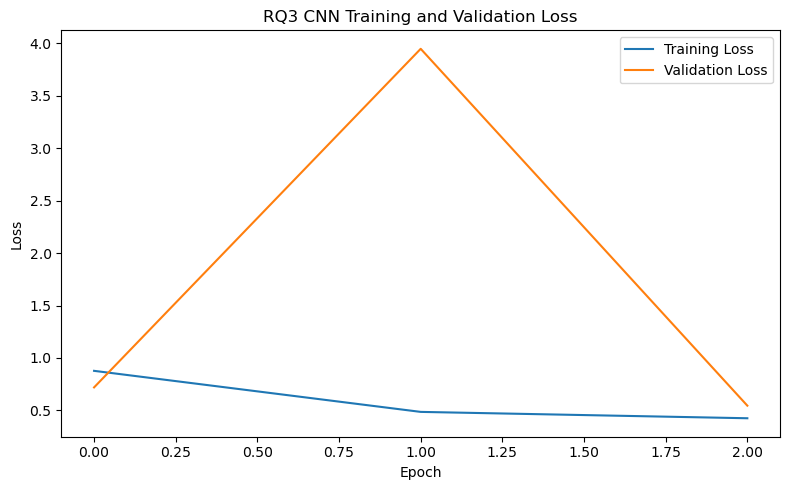

83/83 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step
Test Accuracy: 0.7771084337349398


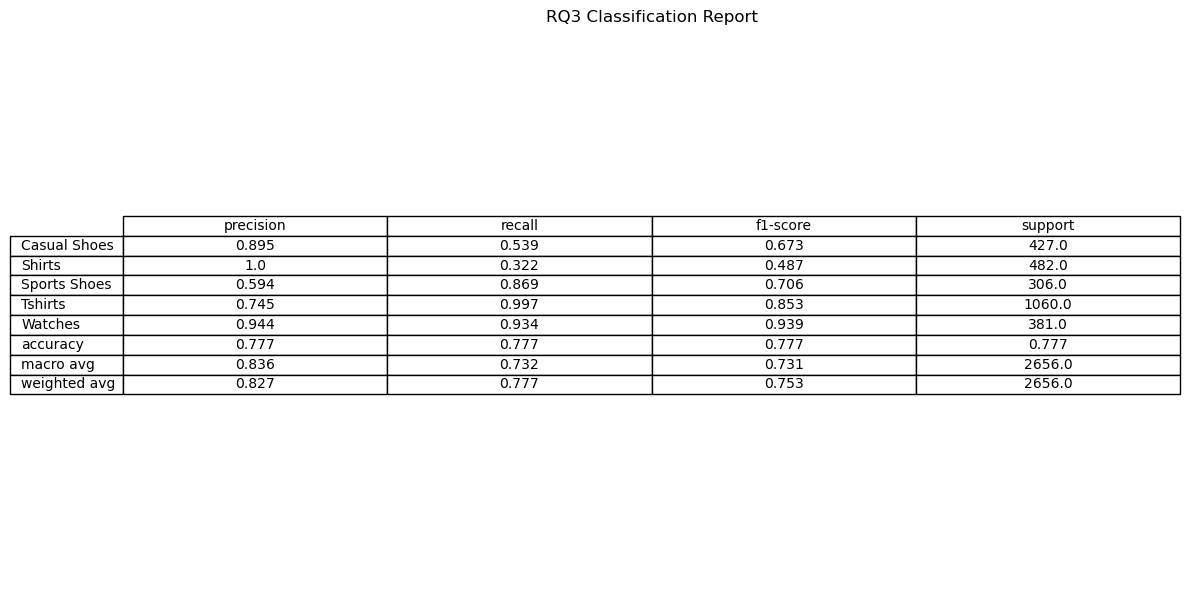

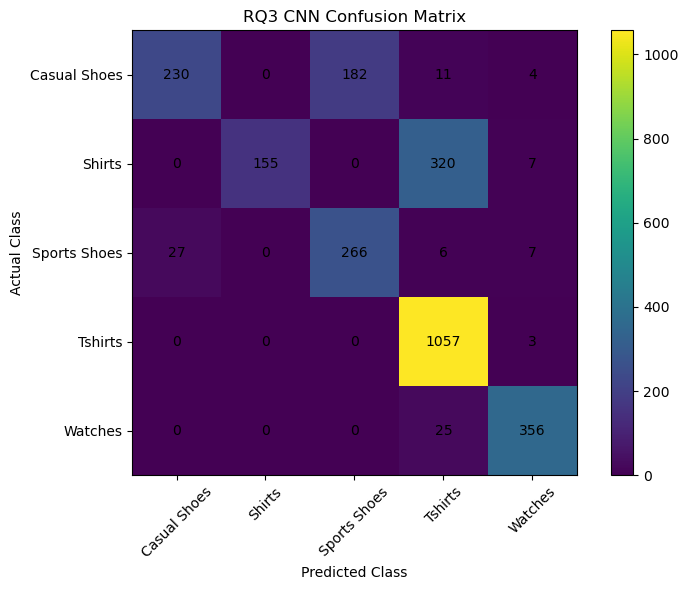

Total misclassified images: 592


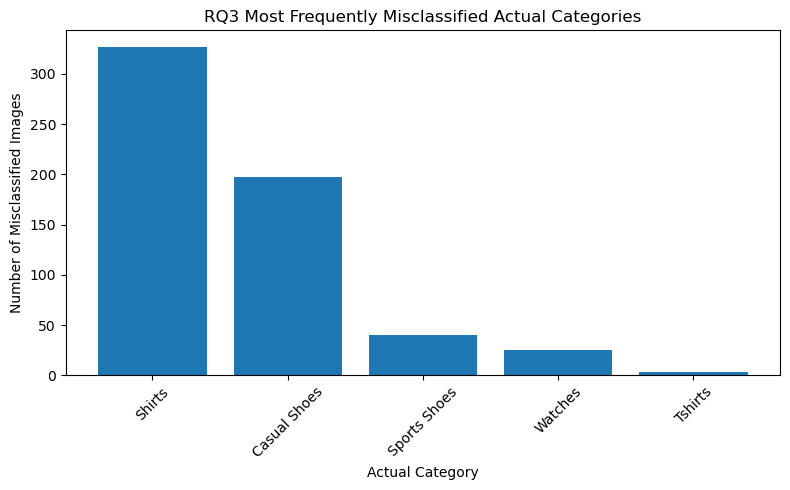

TypeError: can't multiply sequence by non-int of type 'float'

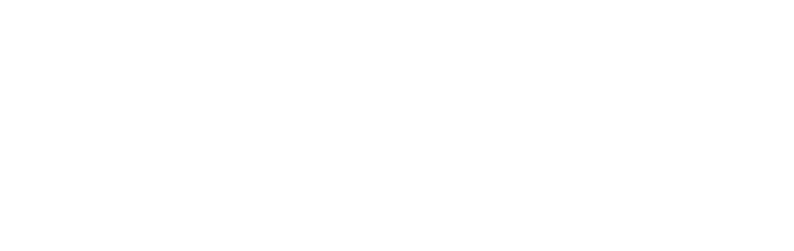

In [2]:
# RQ3: Misclassified Fashion Product Categories Analysis

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


# 1. Create output folders

OUTPUT_DIR = Path("Results_RQ_Outputs")
BASE_DIR = OUTPUT_DIR / "RQ3_Misclassification_Analysis"
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"
TABLE_PNG_DIR = BASE_DIR / "tables_png"
MISCLASSIFIED_DIR = BASE_DIR / "misclassified_images"
MODEL_DIR = BASE_DIR / "models"

for folder in [OUTPUT_DIR, BASE_DIR, FIG_DIR, TABLE_DIR, TABLE_PNG_DIR, MISCLASSIFIED_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# 2. Load CSV files

styles = pd.read_csv("styles.csv", on_bad_lines="skip")
images = pd.read_csv("images.csv")

styles["id"] = styles["id"].astype(str)
styles["filename"] = styles["id"] + ".jpg"

if "filename" in images.columns:
    df = pd.merge(styles, images, on="filename", how="inner")
else:
    df = styles.copy()


# 3. Prepare image paths

IMAGE_FOLDER = Path("images")

df["image_path"] = df["filename"].apply(lambda x: str(IMAGE_FOLDER / x))
df = df[df["image_path"].apply(os.path.exists)].copy()

if len(df) == 0:
    raise ValueError("No images found. Check that JPG files are inside the images folder.")


# 4. Select top 5 article categories

df = df.dropna(subset=["articleType"])

top_classes = df["articleType"].value_counts().head(5).index
df = df[df["articleType"].isin(top_classes)].copy()

print("Selected classes:")
print(df["articleType"].value_counts())


# 5. Dataset description table

dataset_table = pd.DataFrame({
    "Description": [
        "Research Question",
        "Total images used",
        "Target column",
        "Selected classes",
        "Input image size",
        "Model type",
        "Main analysis"
    ],
    "Value": [
        "RQ3: Which fashion product categories are most frequently misclassified by the CNN model?",
        len(df),
        "articleType",
        ", ".join(top_classes),
        "128 x 128",
        "Custom CNN",
        "Confusion matrix, misclassification count, error rate, sample misclassified images"
    ]
})

dataset_table.to_csv(TABLE_DIR / "rq3_dataset_description.csv", index=False)

plt.figure(figsize=(13, 4))
plt.axis("off")
plt.table(
    cellText=dataset_table.values,
    colLabels=dataset_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Dataset Description Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_dataset_description.png", dpi=300)
plt.show()


# 6. Class distribution

class_counts = df["articleType"].value_counts()

class_distribution = class_counts.reset_index()
class_distribution.columns = ["Article Type", "Number of Images"]
class_distribution.to_csv(TABLE_DIR / "rq3_class_distribution.csv", index=False)

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("RQ3 Class Distribution")
plt.xlabel("Article Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_class_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 3))
plt.axis("off")
plt.table(
    cellText=class_distribution.values,
    colLabels=class_distribution.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Class Distribution Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_class_distribution_table.png", dpi=300)
plt.show()


# 7. Train validation test split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["articleType"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["articleType"],
    random_state=42
)

split_table = pd.DataFrame({
    "Split": ["Training", "Validation", "Testing"],
    "Number of Images": [len(train_df), len(val_df), len(test_df)],
    "Percentage": [
        round(len(train_df) / len(df) * 100, 2),
        round(len(val_df) / len(df) * 100, 2),
        round(len(test_df) / len(df) * 100, 2)
    ]
})

split_table.to_csv(TABLE_DIR / "rq3_data_split.csv", index=False)

plt.figure(figsize=(7, 3))
plt.axis("off")
plt.table(
    cellText=split_table.values,
    colLabels=split_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Data Split Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_data_split.png", dpi=300)
plt.show()


# 8. Image generators

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="articleType",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="articleType",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="articleType",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)


# 9. Build CNN model

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


# 10. Save architecture table

architecture_table = pd.DataFrame({
    "Layer": [
        "Conv2D + BatchNorm + MaxPooling",
        "Conv2D + BatchNorm + MaxPooling",
        "Conv2D + BatchNorm + MaxPooling",
        "Flatten",
        "Dense + Dropout",
        "Output Dense Softmax"
    ],
    "Description": [
        "32 filters, 3x3 kernel",
        "64 filters, 3x3 kernel",
        "128 filters, 3x3 kernel",
        "Converts feature maps into vector",
        "128 neurons, ReLU, dropout 0.5",
        f"{num_classes} neurons for article categories"
    ]
})

architecture_table.to_csv(TABLE_DIR / "rq3_cnn_architecture.csv", index=False)

plt.figure(figsize=(10, 3))
plt.axis("off")
plt.table(
    cellText=architecture_table.values,
    colLabels=architecture_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 CNN Architecture Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_cnn_architecture.png", dpi=300)
plt.show()


# 11. Train CNN model

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

cnn_model.save(MODEL_DIR / "rq3_custom_cnn_model.h5")


# 12. Training curves

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("RQ3 CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_accuracy_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("RQ3 CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_loss_curve.png", dpi=300)
plt.show()


# 13. Model prediction

test_generator.reset()

pred_probs = cnn_model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes

test_accuracy = accuracy_score(true_classes, pred_classes)

print("Test Accuracy:", test_accuracy)


# 14. Classification report

report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(TABLE_DIR / "rq3_classification_report.csv")

plt.figure(figsize=(12, 6))
plt.axis("off")
plt.table(
    cellText=np.round(report_df.values, 3),
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Classification Report")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_classification_report.png", dpi=300)
plt.show()


# 15. Confusion matrix

cm = confusion_matrix(true_classes, pred_classes)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(TABLE_DIR / "rq3_confusion_matrix.csv")

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("RQ3 CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_confusion_matrix.png", dpi=300)
plt.show()


# 16. Misclassification dataframe

test_results = test_df.copy().reset_index(drop=True)
test_results["Actual Class"] = [class_names[i] for i in true_classes]
test_results["Predicted Class"] = [class_names[i] for i in pred_classes]
test_results["Prediction Confidence"] = np.max(pred_probs, axis=1)
test_results["Correct Prediction"] = test_results["Actual Class"] == test_results["Predicted Class"]

misclassified_df = test_results[test_results["Correct Prediction"] == False].copy()
misclassified_df.to_csv(TABLE_DIR / "rq3_all_misclassified_images.csv", index=False)

print("Total misclassified images:", len(misclassified_df))


# 17. Most frequently misclassified actual categories

actual_error_counts = misclassified_df["Actual Class"].value_counts().reset_index()
actual_error_counts.columns = ["Actual Category", "Number of Misclassified Images"]

actual_total_counts = test_results["Actual Class"].value_counts().reset_index()
actual_total_counts.columns = ["Actual Category", "Total Test Images"]

actual_error_summary = pd.merge(
    actual_error_counts,
    actual_total_counts,
    on="Actual Category",
    how="left"
)

actual_error_summary["Misclassification Rate"] = (
    actual_error_summary["Number of Misclassified Images"] /
    actual_error_summary["Total Test Images"]
)

actual_error_summary = actual_error_summary.sort_values(
    by="Number of Misclassified Images",
    ascending=False
)

actual_error_summary.to_csv(TABLE_DIR / "rq3_most_misclassified_actual_categories.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(
    actual_error_summary["Actual Category"],
    actual_error_summary["Number of Misclassified Images"]
)
plt.title("RQ3 Most Frequently Misclassified Actual Categories")
plt.xlabel("Actual Category")
plt.ylabel("Number of Misclassified Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_most_misclassified_actual_categories.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 3))
plt.axis("off")
plt.table(
    cellText=np.round(actual_error_summary.values, 3),
    colLabels=actual_error_summary.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Most Misclassified Actual Categories Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_most_misclassified_actual_categories.png", dpi=300)
plt.show()


# 18. Most common actual-predicted error pairs

error_pairs = misclassified_df.groupby(
    ["Actual Class", "Predicted Class"]
).size().reset_index(name="Error Count")

error_pairs = error_pairs.sort_values(by="Error Count", ascending=False)
error_pairs.to_csv(TABLE_DIR / "rq3_common_error_pairs.csv", index=False)

plt.figure(figsize=(10, 5))
top_error_pairs = error_pairs.head(10).copy()
top_error_pairs["Pair"] = top_error_pairs["Actual Class"] + " → " + top_error_pairs["Predicted Class"]

plt.bar(top_error_pairs["Pair"], top_error_pairs["Error Count"])
plt.title("RQ3 Top Misclassification Pairs")
plt.xlabel("Actual → Predicted")
plt.ylabel("Error Count")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_top_misclassification_pairs.png", dpi=300)
plt.show()

plt.figure(figsize=(12, 4))
plt.axis("off")
plt.table(
    cellText=top_error_pairs[["Actual Class", "Predicted Class", "Error Count"]].values,
    colLabels=["Actual Class", "Predicted Class", "Error Count"],
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Top Misclassification Pairs Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_top_misclassification_pairs.png", dpi=300)
plt.show()


# 19. Predicted categories receiving most wrong predictions

wrong_prediction_counts = misclassified_df["Predicted Class"].value_counts().reset_index()
wrong_prediction_counts.columns = ["Predicted Category", "Number of Wrong Predictions"]
wrong_prediction_counts.to_csv(TABLE_DIR / "rq3_wrong_prediction_categories.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(
    wrong_prediction_counts["Predicted Category"],
    wrong_prediction_counts["Number of Wrong Predictions"]
)
plt.title("RQ3 Categories Most Often Predicted Incorrectly")
plt.xlabel("Predicted Category")
plt.ylabel("Number of Wrong Predictions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_wrong_prediction_categories.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 3))
plt.axis("off")
plt.table(
    cellText=wrong_prediction_counts.values,
    colLabels=wrong_prediction_counts.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Wrong Prediction Categories Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_wrong_prediction_categories.png", dpi=300)
plt.show()


# 20. Save sample misclassified images

sample_misclassified = misclassified_df.head(12).copy()

plt.figure(figsize=(12, 8))

for idx, row in enumerate(sample_misclassified.itertuples()):
    img = plt.imread(row.image_path)
    plt.subplot(3, 4, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        "A: " + str(row._asdict()["Actual Class"]) +
        "\nP: " + str(row._asdict()["Predicted Class"]),
        fontsize=8
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "rq3_sample_misclassified_images.png", dpi=300)
plt.show()


# 21. Error reason table

possible_reasons = pd.DataFrame({
    "Possible Reason": [
        "Visual similarity between categories",
        "Small or unclear product details",
        "Similar colors and shapes",
        "Class imbalance",
        "Background noise or image quality",
        "Limited model depth"
    ],
    "Explanation": [
        "Some fashion categories may look very similar, so the CNN may confuse them.",
        "Important product features may be small after resizing images to 128 x 128.",
        "Products with similar silhouettes, colors, and textures can produce similar CNN features.",
        "Categories with fewer images may be learned less effectively.",
        "Different backgrounds, lighting, or low-quality images can reduce prediction accuracy.",
        "A simple custom CNN may not capture complex fashion-specific visual patterns."
    ]
})

possible_reasons.to_csv(TABLE_DIR / "rq3_possible_reasons_for_errors.csv", index=False)

plt.figure(figsize=(14, 4))
plt.axis("off")
plt.table(
    cellText=possible_reasons.values,
    colLabels=possible_reasons.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Possible Reasons for Misclassification")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_possible_reasons_for_errors.png", dpi=300)
plt.show()


# 22. Final RQ3 answer table

if len(actual_error_summary) > 0:
    most_misclassified_category = actual_error_summary.iloc[0]["Actual Category"]
else:
    most_misclassified_category = "No misclassified category found"

if len(error_pairs) > 0:
    most_common_pair = (
        error_pairs.iloc[0]["Actual Class"] +
        " predicted as " +
        error_pairs.iloc[0]["Predicted Class"]
    )
else:
    most_common_pair = "No error pair found"

final_answer_table = pd.DataFrame({
    "Research Question": [
        "Which fashion product categories are most frequently misclassified by the CNN model?"
    ],
    "Most Misclassified Category": [most_misclassified_category],
    "Most Common Error Pair": [most_common_pair],
    "Possible Reason": [
        "Misclassification is mainly caused by visual similarity, small image details, class imbalance, and limited CNN feature extraction."
    ],
    "Test Accuracy": [str(round(test_accuracy * 100, 2)) + "%"]
})

final_answer_table.to_csv(TABLE_DIR / "rq3_final_answer.csv", index=False)

plt.figure(figsize=(15, 3))
plt.axis("off")
plt.table(
    cellText=final_answer_table.values,
    colLabels=final_answer_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ3 Final Answer Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq3_final_answer.png", dpi=300)
plt.show()


# 23. Save training history

history_table = pd.DataFrame({
    "Epoch": list(range(1, len(history.history["accuracy"]) + 1)),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

history_table.to_csv(TABLE_DIR / "rq3_training_history.csv", index=False)

print("RQ3 completed successfully.")
print("All outputs saved in:", BASE_DIR)
print("Figures saved in:", FIG_DIR)
print("CSV tables saved in:", TABLE_DIR)
print("PNG tables saved in:", TABLE_PNG_DIR)
print("Misclassified image analysis saved in:", MISCLASSIFIED_DIR)
print("Model saved in:", MODEL_DIR)